# Conversation Preparation for Structure Analysis

This notebook prepares one-to-one Conti chat histories for downstream social graph analysis. It loads raw Chat and Jabber logs, merges user aliases, removes non-interactive and invalid conversations, removes encrypted messages, evaluates several conversation segmentation strategies, and saves the final conversation-unit graph as a pickle file.

## Load and normalize conversation histories

This section loads messages from the chat and Jabber logs, applies the user alias mapping, and organizes messages into undirected one-to-one conversation histories. Each conversation is keyed by a pair of users and sorted chronologically.

In [7]:
import json
file_path_1 = '../../data/logs/chat_logs.json'
file_path_2 = '../../data/logs/jabber_logs.json'
def count_messages(file_path): 
    with open(file_path, "r") as json_file:
        data = json.load(json_file)
        # Count the objects
    if isinstance(data, list):
        count = len(data)
    elif isinstance(data, dict):
        count = len(data.keys())
    else:
        count = 0
    return count

print(f"Number of objects in the {file_path_1} file: {count_messages(file_path_1)} and in the {file_path_2} file: {count_messages(file_path_2)}. And total: {count_messages(file_path_1)+count_messages(file_path_2)}")

Number of objects in the ../../data/logs/chat_logs.json file: 107967 and in the ../../data/logs/jabber_logs.json file: 60657. And total: 168624


In [1]:
import json
from functions import time_parser, all_conversations_sorted, count_files_in_folder, count_unique_users_in_conversations, split_to_txt_files
import csv
import os
import pandas as pd

all_conversations = all_conversations_sorted() # load all messages in conversation histories

Initial total message count: 168624
Total processed message count: 168624
Message counts match.


## Clean conversation for analysis

This section identifies conversations where only one user sends messages. These are removed from the main structure analysis because they often correspond to announcements, prompts, authorization messages, or other non-interactive exchanges rather than reciprocal communication.

Then keeps only two-way conversations, defined as histories where both users send at least one message. These conversations form the basis for modeling social interaction between Conti members.

Then filters short conversations that appear to be platform glitches, where the same message is repeated back across users. These cases are removed to avoid creating artificial edges in the social graph.

Then removes messages that contain only the encrypted-message error placeholder. These entries do not contain interpretable conversational content and are excluded before segmentation.

In [2]:
from functions import filter_single_speaker_conversations, count_conversations

# Filter conversations with only one speaker
single_speaker_conversations = filter_single_speaker_conversations(all_conversations)

# Count single-speaker and total conversations accurately
num_single_speaker_conversations = count_conversations(single_speaker_conversations)
num_all_conversations = count_conversations(all_conversations)
num_two_way_conversations = num_all_conversations - num_single_speaker_conversations

print(f"Number of single-speaker conversations: {num_single_speaker_conversations} out of {num_all_conversations}")
print(f"Number of two-way conversations: {num_two_way_conversations}")

Number of single-speaker conversations: 936 out of 2426
Number of two-way conversations: 1490


In [3]:
from functions import filter_two_way_conversations

# Filter to get only two-way conversations
two_way_conversations = filter_two_way_conversations(all_conversations, single_speaker_conversations)

# Calculate the number of unique users involved in two-way conversations
unique_two_way_user_count = count_unique_users_in_conversations(two_way_conversations)
print(f"Number of unique users involved in two-way conversations: {unique_two_way_user_count}")

Number of unique users involved in two-way conversations: 318


In [4]:
from functions import filter_out_glitch_conversations

valid_conversations = filter_out_glitch_conversations(two_way_conversations)
print(f"Number of valid conversations: {count_conversations(valid_conversations)}")
print(f"Number of unique users involved in two-way conversations: {count_unique_users_in_conversations(valid_conversations)}")


Number of valid conversations: 1456
Number of unique users involved in two-way conversations: 301


In [5]:
# delete messages that are encrypted aka are just "[Ошибка: сообщение зашифровано, и невозможно его расшифровать.]"
from functions import remove_encrypted_messages
# Apply the function and get the counts
unencrypt_valid_conversations, before_count, after_count = remove_encrypted_messages(valid_conversations)

# Print the summary
print(f"Total messages before removal: {before_count}")
print(f"Total messages after removal: {after_count}")
print(f"Total messages removed: {before_count - after_count}")


Total messages before removal: 165183
Total messages after removal: 150811
Total messages removed: 14372


In [6]:
print(f"Number of valid conversations: {count_conversations(unencrypt_valid_conversations)}")
print(f"Number of unique users involved in two-way conversations: {count_unique_users_in_conversations(unencrypt_valid_conversations)}")

Number of valid conversations: 1456
Number of unique users involved in two-way conversations: 301


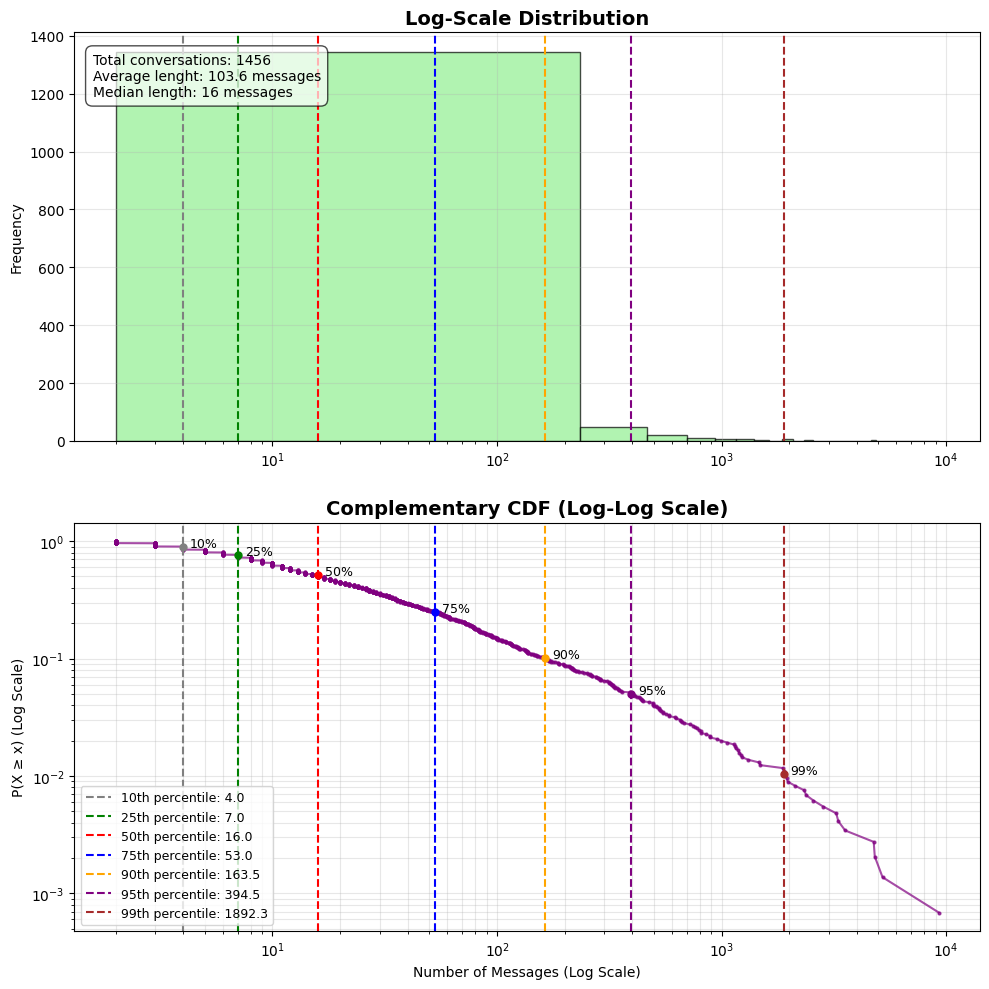

Percentile values:
10th percentile: 4.0 messages
25th percentile: 7.0 messages
50th percentile: 16.0 messages
75th percentile: 53.0 messages
90th percentile: 163.5 messages
95th percentile: 394.5 messages
99th percentile: 1892.3 messages


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Get message counts for each conversation
messages_per_conversation = []
for user_i in unencrypt_valid_conversations.keys():
    for user_j, messages in unencrypt_valid_conversations[user_i].items():
        messages_per_conversation.append(len(messages))

# Calculate key statistics
min_messages = min(messages_per_conversation)
max_messages = max(messages_per_conversation)
mean_messages = np.mean(messages_per_conversation)
median_messages = np.median(messages_per_conversation)
std_messages = np.std(messages_per_conversation)

# Calculate percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(messages_per_conversation, percentiles)
percentile_dict = {p: v for p, v in zip(percentiles, percentile_values)}

# Create CCDF data
message_counts = sorted(messages_per_conversation)
ccdf = [1 - i/len(message_counts) for i in range(len(message_counts))]

# Define colors for percentile lines
colors = ['grey', 'green', 'red', 'blue', 'orange', 'purple', 'brown']

# Create a figure with two subplots, one below the other
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

# 1. Log-scale histogram (top)
ax1 = plt.subplot(gs[0])
ax1.hist(messages_per_conversation, bins=40, alpha=0.7, color='lightgreen', edgecolor='black')
ax1.set_xscale('log')
ax1.set_title('Log-Scale Distribution', fontsize=14, fontweight='bold')
# ax1.set_xlabel('Number of Messages (Log Scale)')
ax1.set_ylabel('Frequency')
ax1.grid(axis='both', alpha=0.3)

# Add percentile lines to log plot
for i, p in enumerate(percentiles):
    value = percentile_values[i]
    ax1.axvline(x=value, color=colors[i], linestyle='--', linewidth=1.5,
               label=f'{p}th percentile: {value:.1f}')

# Add statistics text box
stats_text = (f"Total conversations: {len(messages_per_conversation)}\n"
              f"Average lenght: {mean_messages:.1f} messages\n"
              f"Median length: {median_messages:.0f} messages")
ax1.text(0.02, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.5'),
        verticalalignment='top')

# ax1.legend(loc='upper right', fontsize=9)

# 2. CCDF (Complementary Cumulative Distribution Function) (bottom)
ax2 = plt.subplot(gs[1])
ax2.plot(message_counts, ccdf, 'o-', markersize=2, color='purple', alpha=0.7)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Complementary CDF (Log-Log Scale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Messages (Log Scale)')
ax2.set_ylabel('P(X ≥ x) (Log Scale)')
ax2.grid(True, which="both", ls="-", alpha=0.3)

# Add vertical lines for percentiles in CCDF
for i, p in enumerate(percentiles):
    value = percentile_values[i]
    # Find the corresponding y-value in the CCDF
    idx = np.searchsorted(message_counts, value)
    if idx < len(ccdf):
        y_value = ccdf[idx]
        ax2.axvline(x=value, color=colors[i], linestyle='--', linewidth=1.5,
                   label=f'{p}th percentile: {value:.1f}')
        ax2.plot([value], [y_value], 'o', color=colors[i], markersize=5)
        ax2.annotate(f"{p}%", (value, y_value), xytext=(5, 0), 
                    textcoords='offset points', fontsize=9)

ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
# plt.suptitle('Message Count Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# Print percentile information
print("Percentile values:")
for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.1f} messages")

## Define conversation units

This section evaluates methods for splitting long conversation histories into smaller conversation units. A conversation unit is intended to represent a coherent interaction or discussion within a larger user-pair history.

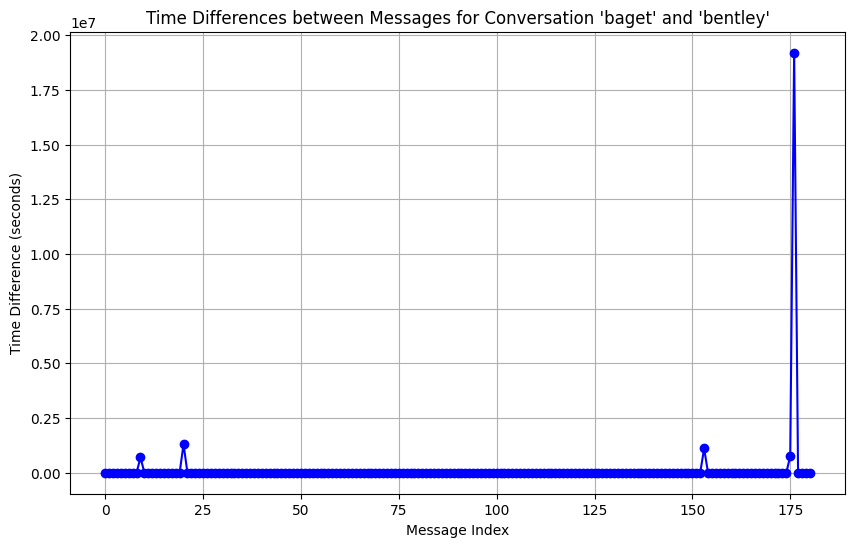

In [ ]:
# let's plot an example bentley<>baget conversation history (time diff vs message order) (should be 5)

import matplotlib.pyplot as plt
from datetime import datetime


# Extract the specific conversation
messages = unencrypt_valid_conversations['baget']['bentley']

# Calculate time differences between consecutive messages
time_diffs = [(messages[i][0] - messages[i - 1][0]).total_seconds() for i in range(1, len(messages))]

# Plotting the time differences
plt.figure(figsize=(10, 6))
plt.plot(time_diffs, marker='o', linestyle='-', color='b')
plt.title("Time Differences between Messages for Conversation 'baget' and 'bentley'")
plt.xlabel("Message Index")
plt.ylabel("Time Difference (seconds)")
plt.grid(True)
plt.show()



## Date-based segmentation

This baseline method splits conversations by calendar date. It is simple and interpretable, but may incorrectly split conversations that continue across midnight or merge multiple independent exchanges occurring on the same day.

In [9]:
from functions import segment_conversations_by_date
# Example usage:
conversation_segments_by_date = segment_conversations_by_date(unencrypt_valid_conversations)

# Print out segmentation for a specific conversation (baget & bentley)
for (user_i, user_j), segments in conversation_segments_by_date.items():
    if user_i == 'baget' and user_j == 'bentley':
        print(f"\nConversation between {user_i} and {user_j} segmented into {len(segments)} units (by date):")
        for idx, unit in enumerate(segments):
            print(f"\n--- Conversation Unit {idx + 1} (Date: {unit[0][0].date()}) ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")



Conversation between baget and bentley segmented into 6 units (by date):

--- Conversation Unit 1 (Date: 2020-07-14) ---
2020-07-14 10:09:44.299871 - baget: Привет!
2020-07-14 10:10:10.468742 - bentley: Привет
2020-07-14 10:10:30.003039 - baget: Дружище, на полный прогон бекдор тебе отдавать?
2020-07-14 10:11:27.089405 - bentley: Да давай.
2020-07-14 10:11:31.415445 - bentley: У тебя с лоадером?
2020-07-14 10:11:40.908001 - baget: Да, конечно.
2020-07-14 10:12:36.159792 - baget: Тебе сбросить исходники или прислать бинарники или как?:-)
2020-07-14 10:13:55.345640 - baget: Процедурный, так сказать, момент...:-)
2020-07-14 10:15:31.565169 - bentley: Лучше ехею Мы его криптанем и проверим
2020-07-14 10:16:23.003953 - baget: ок

--- Conversation Unit 2 (Date: 2020-07-22) ---
2020-07-22 12:37:22.872208 - bentley: Привет.
2020-07-22 12:37:26.764586 - bentley: Можешь помочь?
2020-07-22 12:37:41.573869 - baget: Привет.
2020-07-22 12:37:44.172126 - baget: Говори.
2020-07-22 12:37:49.160448 - b

In [10]:
total_conversation_units = sum(len(segments) for segments in conversation_segments_by_date.values())
print(f"Total number of conversation units: {total_conversation_units}")

Total number of conversation units: 16114


In [16]:
# average units per conversation
# Calculate the average number of units per conversation
conversation_units_per_conversation = [
    len(segments) for segments in conversation_segments_by_date.values()
]
average_units = sum(conversation_units_per_conversation) / len(conversation_units_per_conversation)
print(f"Average number of conversation units per conversation: {average_units:.2f}")
# maximum number of units
max_units = max(conversation_units_per_conversation)
print(f"Maximum number of conversation units in a single conversation: {max_units}")
# minimum number of units
min_units = min(conversation_units_per_conversation)
print(f"Minimum number of conversation units in a single conversation: {min_units}")

Average number of conversation units per conversation: 11.07
Maximum number of conversation units in a single conversation: 242
Minimum number of conversation units in a single conversation: 1


## Greeting-based segmentation

This method splits conversations when greeting expressions are detected. It is useful as a heuristic baseline, but may underperform because users do not always begin new conversations with greetings and some greetings occur within ongoing exchanges.

In [ ]:
import re

def is_greeting(text):
    greetings_pattern = r"\b(привет|здравствуй|здравствуйте|доброе утро|добрый день|добрый вечер|салют|хай)\b"
    return re.search(greetings_pattern, text, flags=re.IGNORECASE) is not None


def is_other_greeting(current_unit, current_user):
    """
    Checks if the previous message is from another user and if any message
    from that user's last turn contains a greeting.
    
    Parameters:
        current_unit (list): The conversation unit (list of messages).
        current_user (str): The sender of the current message.
    
    Returns:
        bool: True if the other user's last turn contains a greeting, False otherwise.
    """
    if not current_unit:
        return False  # No messages in the unit yet

    last_user = current_unit[-1][1]  # Get the sender of the last message
    if last_user == current_user:
        return False  # The previous message was from the same user, no turn change

    # Find the last turn of messages from the other user
    last_turn_messages = []
    for msg in reversed(current_unit):
        if msg[1] == last_user:
            last_turn_messages.append(msg)
        else:
            break  # Stop when a different user is found

    # Check if any message in the last turn contains a greeting
    return any(is_greeting(msg[3]) for msg in last_turn_messages)


def segment_conversation_by_greetings(messages):

    if not messages:
        return []
    
    conversation_units = []
    current_unit = [messages[0]]
    
    for i in range(1, len(messages)):
        curr_msg = messages[i]
        curr_msg_text = curr_msg[3]
        curr_msg_sender = curr_msg[1]
        
        if is_greeting(curr_msg_text):
            # Check if the other user has greeted already in this unit
            if is_other_greeting(current_unit, curr_msg_sender):
                # It's a reply greeting => stay in the same unit
                current_unit.append(curr_msg)
            else:
                # Potentially start a new unit 
                # only if the current unit is 'substantive' enough
                # if len(current_unit) >= min_unit_size:
                conversation_units.append(current_unit)
                current_unit = [curr_msg]
                # else:
                #     # If too few messages so far, treat this as part of the same unit
                #     current_unit.append(curr_msg)
        else:
            # Non-greeting => always add to the current unit
            current_unit.append(curr_msg)
    
    # Append the last unit
    if current_unit:
        conversation_units.append(current_unit)
    
    return conversation_units

def process_conversations_by_greetings(conversations_dict, min_unit_size=2):
    """
    Process each conversation and segment it by greeting words.
    
    Returns:
      conversation_segments (dict):
        Keys: (user_i, user_j) tuples
        Values: lists of conversation units
    """
    conversation_segments = {}
    
    for user_i, threads in conversations_dict.items():
        for user_j, messages in threads.items():
            segments = segment_conversation_by_greetings(messages)
            conversation_segments[(user_i, user_j)] = segments
    
    return conversation_segments

conversation_segments_by_greetings = process_conversations_by_greetings(unencrypt_valid_conversations)

# Print out segmentation for a specific conversation (baget & bentley):
for (user_i, user_j), segments in conversation_segments_by_greetings.items():
    if user_i == 'baget' and user_j == 'stern':
        print(f"\nConversation between {user_i} and {user_j} segmented into {len(segments)} units:")
        for idx, unit in enumerate(segments):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                # Adjust indices if your message structure differs
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")




Conversation between baget and stern segmented into 30 units:

--- Conversation Unit 1 ---
2020-06-22 08:43:19.957882 - stern: Привет
2020-06-22 08:43:20.802614 - stern: как делла
2020-06-22 08:43:24.130109 - stern: как там с лоадером
2020-06-22 08:44:09.773632 - baget: Пивет.

--- Conversation Unit 2 ---
2020-06-22 08:44:12.623915 - baget: Привет.
2020-06-22 08:44:30.517453 - baget: По локеру - отдал в пятницу.
2020-06-22 08:44:43.304340 - baget: Бекдор отдам сегодня - завтра.
2020-06-22 08:44:57.022613 - baget: Он по частям готов, теперь  один модуль собираю.
2020-06-22 08:45:25.802313 - baget: А лоадер? Так это часть бекдора... Он давно готов.
2020-06-22 08:51:28.479403 - stern: lf
2020-06-22 08:51:29.351636 - stern: да
2020-06-22 08:51:30.277809 - stern: я про бк
2020-06-22 08:53:00.801226 - baget: Бк мы по - пунктам ТЗ фактически весь реализовали, но раскладывали функционал по отдельным проектикам. Осталось теперь до кучи склеить и бк готов.
2020-06-22 08:53:42.822675 - baget: Се

In [72]:
total_conversation_units = sum(len(segments) for segments in conversation_segments_by_greetings.values())
print(f"Total number of conversation units: {total_conversation_units}")


Total number of conversation units: 10740


## Fixed time-threshold segmentation

This method splits conversations whenever the time gap between consecutive messages exceeds a fixed threshold. It provides a simple time-based baseline but may over-segment slow conversations or under-segment fast recurring exchanges.

In [73]:
def segment_conversation_by_fixed_threshold(messages, threshold_seconds=3600):
    """
    Segment a conversation into units based on a fixed time threshold.
    
    Parameters:
    - messages: List of message tuples (timestamp, user, message_id, content)
    - threshold_seconds: Time gap threshold in seconds (default: 3600 seconds = 1 hour)
    
    Returns:
    - List of conversation units
    """
    # Handle empty message list
    if not messages:
        return []
    
    conversation_units = []
    current_unit = [messages[0]]
    
    for i in range(1, len(messages)):
        # Calculate time difference between current and previous message
        time_gap = (messages[i][0] - messages[i-1][0]).total_seconds()
        
        # If gap exceeds threshold, start a new unit
        if time_gap > threshold_seconds:
            conversation_units.append(current_unit)
            current_unit = [messages[i]]
        else:
            # Otherwise, add to current unit
            current_unit.append(messages[i])
    
    # Add the final unit
    if current_unit:
        conversation_units.append(current_unit)
    
    return conversation_units


def process_conversations(conversations_dict, threshold_seconds=3600):
    conversation_segments = {}
    
    for user_i in conversations_dict.keys():
        for user_j, messages in conversations_dict[user_i].items():
            # Segment the conversation using fixed threshold
            conversation_units = segment_conversation_by_fixed_threshold(
                messages, 
                threshold_seconds=threshold_seconds
            )
            conversation_segments[(user_i, user_j)] = conversation_units
    
    return conversation_segments


# Usage example:
# Segment conversations with a 1-hour threshold
threshold_in_seconds = 3600  # 1 hour
conversation_segments_fixed = process_conversations(unencrypt_valid_conversations, threshold_seconds=threshold_in_seconds)

# Display a sample conversation with segmented units
for (user_i, user_j), units in conversation_segments_fixed.items():
    if user_i == 'baget' and user_j == 'stern':
        print(f"\nConversation between {user_i} and {user_j} split into {len(units)} units:")
        for idx, unit in enumerate(units):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")


Conversation between baget and stern split into 58 units:

--- Conversation Unit 1 ---
2020-06-22 08:43:19.957882 - stern: Привет
2020-06-22 08:43:20.802614 - stern: как делла
2020-06-22 08:43:24.130109 - stern: как там с лоадером
2020-06-22 08:44:09.773632 - baget: Пивет.
2020-06-22 08:44:12.623915 - baget: Привет.
2020-06-22 08:44:30.517453 - baget: По локеру - отдал в пятницу.
2020-06-22 08:44:43.304340 - baget: Бекдор отдам сегодня - завтра.
2020-06-22 08:44:57.022613 - baget: Он по частям готов, теперь  один модуль собираю.
2020-06-22 08:45:25.802313 - baget: А лоадер? Так это часть бекдора... Он давно готов.
2020-06-22 08:51:28.479403 - stern: lf
2020-06-22 08:51:29.351636 - stern: да
2020-06-22 08:51:30.277809 - stern: я про бк
2020-06-22 08:53:00.801226 - baget: Бк мы по - пунктам ТЗ фактически весь реализовали, но раскладывали функционал по отдельным проектикам. Осталось теперь до кучи склеить и бк готов.
2020-06-22 08:53:42.822675 - baget: Сейчас этим и занят.
2020-06-22 08:

In [74]:
total_conversation_units = sum(len(segments) for segments in conversation_segments_fixed.values())
print(f"Total number of conversation units: {total_conversation_units}")

Total number of conversation units: 22888


## Spike-based segmentation

This method detects unusually large time gaps relative to prior message timing within a conversation. It is tested as a dynamic alternative to a single fixed threshold.

In [75]:
import re
import numpy as np
from datetime import timedelta

def calculate_time_differences(messages):
    """Calculate the time difference between each consecutive message."""
    return [(messages[i][0] - messages[i - 1][0]).total_seconds() for i in range(1, len(messages))]

def segment_conversation_by_spike(messages, spike_factor=100):
    """Segment a conversation based on time difference spikes, using dynamic average time difference of previous units."""
    conversation_units = []
    current_unit = [messages[0]]
    unit_average_diffs = []  # To track average time difference per unit

    # Calculate time differences for the messages
    time_diffs = calculate_time_differences(messages)

    for i in range(1, len(messages)):
        time_gap = time_diffs[i - 1]

        # Check if the first time difference is greater than the average of previous units
        avg_time_diff = np.mean(unit_average_diffs) if unit_average_diffs else 0
        if avg_time_diff > 0 and time_gap > spike_factor * avg_time_diff:
            # If condition met, treat the first message as a separate unit
            conversation_units.append(current_unit)
            unit_average_diffs.append(avg_time_diff)  # Record the average difference of this unit
            current_unit = [messages[i]]  # Start a new unit with the current message
            continue
        
        # Calculate the median time difference of the current unit
        current_diffs = calculate_time_differences(current_unit)
        median_diff = np.median(current_diffs) if current_diffs else 0

        # Determine the threshold based on spike factor and median of current unit
        threshold = spike_factor * median_diff

        # Check if the time gap exceeds the dynamic threshold for regular segmentation
        if time_gap > threshold and median_diff > 0:
            # Calculate and store the average time difference for the current unit
            avg_diff = np.mean(current_diffs) if current_diffs else 0
            unit_average_diffs.append(avg_diff)
            # Append the current unit to the list of conversation units and start a new one
            conversation_units.append(current_unit)
            current_unit = [messages[i]]
        else:
            # Continue adding messages to the current unit
            current_unit.append(messages[i])

    # Append the last unit and its average difference
    if current_unit:
        conversation_units.append(current_unit)
        avg_diff = np.mean(calculate_time_differences(current_unit))
        unit_average_diffs.append(avg_diff)

    return conversation_units, unit_average_diffs

def process_conversations(conversations_dict, spike_factor=100):
    """Process each conversation and segment it into units based on spikes."""
    conversation_segments = {}
    all_unit_averages = []

    for user_i in conversations_dict.keys():
        for user_j, messages in conversations_dict[user_i].items():
            # Segment the conversation into units and collect average diffs
            conversation_units, unit_averages = segment_conversation_by_spike(messages, spike_factor=spike_factor)
            conversation_segments[(user_i, user_j)] = conversation_units
            all_unit_averages.extend(unit_averages)  # Collect all unit averages


    return conversation_segments, all_unit_averages

# Segment convo histories
spike_factor = 700
conversation_segments_by_spikes, all_unit_averages = process_conversations(unencrypt_valid_conversations, spike_factor)

# Display a sample conversation with segmented units
for (user_i, user_j), units in conversation_segments_by_spikes.items():
    if user_i == 'baget' and user_j == 'stern':
        print(f"\nConversation between {user_i} and {user_j} split into {len(units)} units:")
        for idx, unit in enumerate(units):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Conversation between baget and stern split into 48 units:

--- Conversation Unit 1 ---
2020-06-22 08:43:19.957882 - stern: Привет
2020-06-22 08:43:20.802614 - stern: как делла
2020-06-22 08:43:24.130109 - stern: как там с лоадером
2020-06-22 08:44:09.773632 - baget: Пивет.
2020-06-22 08:44:12.623915 - baget: Привет.
2020-06-22 08:44:30.517453 - baget: По локеру - отдал в пятницу.
2020-06-22 08:44:43.304340 - baget: Бекдор отдам сегодня - завтра.
2020-06-22 08:44:57.022613 - baget: Он по частям готов, теперь  один модуль собираю.
2020-06-22 08:45:25.802313 - baget: А лоадер? Так это часть бекдора... Он давно готов.
2020-06-22 08:51:28.479403 - stern: lf
2020-06-22 08:51:29.351636 - stern: да
2020-06-22 08:51:30.277809 - stern: я про бк
2020-06-22 08:53:00.801226 - baget: Бк мы по - пунктам ТЗ фактически весь реализовали, но раскладывали функционал по отдельным проектикам. Осталось теперь до кучи склеить и бк готов.
2020-06-22 08:53:42.822675 - baget: Сейчас этим и занят.
2020-06-22 08:

In [76]:
total_conversation_units = sum(len(segments) for segments in conversation_segments_by_spikes.values())
print(f"Total number of conversation units: {total_conversation_units}")

Total number of conversation units: 19414


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


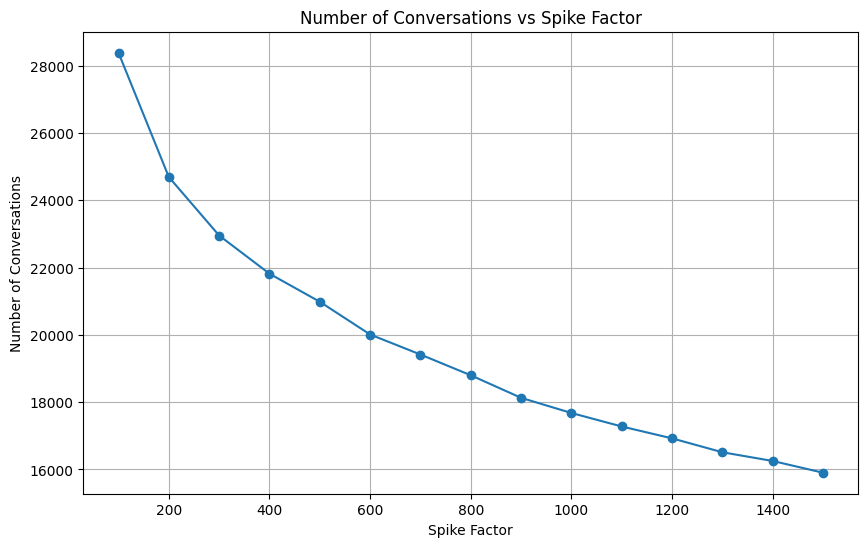

In [36]:
# plot number of convrsations vs spike factor
spike_factors = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
conversation_counts = []
for factor in spike_factors:
    conversation_segments_by_spikes, _ = process_conversations(unencrypt_valid_conversations, factor)
    conversation_counts.append(sum(len(segments) for segments in conversation_segments_by_spikes.values()))
plt.figure(figsize=(10, 6))
plt.plot(spike_factors, conversation_counts, marker='o')
plt.title("Number of Conversations vs Spike Factor")
plt.xlabel("Spike Factor")
plt.ylabel("Number of Conversations")
plt.grid(True)
plt.show()


## Percentile-based segmentation

This method uses the distribution of time gaps within each conversation history to define a dynamic segmentation threshold. The final method uses the 90th percentile of time differences, bounded between 30 minutes and 12 hours, to avoid over-splitting rapid conversations and under-splitting conversations with very long pauses.

In [124]:
import re
import numpy as np
from datetime import timedelta

def calculate_time_differences(messages):
    """Calculate the time difference between each consecutive message."""
    return [(messages[i][0] - messages[i - 1][0]).total_seconds() for i in range(1, len(messages))]

def segment_conversation_with_percentile_threshold(messages, percentile=90, min_threshold_minutes=30, max_threshold_hours=12):
    """
    Segment conversations using a percentile-based threshold on time differences
    
    Parameters:
    - messages: List of message tuples
    - percentile: Which percentile of time gaps to use as threshold (e.g., 90)
    - min_threshold_minutes: Minimum threshold in minutes
    - max_threshold_hours: Maximum threshold in hours
    
    Returns:
    - List of conversation units
    """
    conversation_units = []
    current_unit = [messages[0]]
    
    # Calculate all time differences
    time_diffs = calculate_time_differences(messages)
    
    # Set minimum and maximum thresholds (in seconds)
    min_threshold = min_threshold_minutes * 60
    max_threshold = max_threshold_hours * 3600
    
    # Calculate percentile-based threshold
    if len(time_diffs) >= 5:
        percentile_threshold = np.percentile(time_diffs, percentile)
        # Bound the threshold between min and max
        threshold = max(min_threshold, min(percentile_threshold, max_threshold))
    else:
        threshold = min_threshold  # Default to minimum for short conversations
        print(f"Warning: Not enough data points to calculate percentile threshold. Using minimum threshold of {min_threshold_minutes} minutes.")
    
    # Apply the threshold to segment the conversation
    for i in range(1, len(messages)):
        time_gap = time_diffs[i-1]
        
        if time_gap > threshold:
            conversation_units.append(current_unit)
            current_unit = [messages[i]]
        else:
            current_unit.append(messages[i])
    
    # Add the last unit
    if current_unit:
        conversation_units.append(current_unit)
    
    return conversation_units

def process_conversations_with_percentile(conversations_dict, percentile=90, min_threshold_minutes=30, max_threshold_hours=12):
    """Process each conversation and segment it using percentile-based threshold."""
    conversation_segments = {}
    thresholds_used = []

    for user_i in conversations_dict.keys():
        for user_j, messages in conversations_dict[user_i].items():                
            # Segment the conversation using percentile-based threshold
            conversation_units = segment_conversation_with_percentile_threshold(
                messages, 
                percentile=percentile,
                min_threshold_minutes=min_threshold_minutes,
                max_threshold_hours=max_threshold_hours
            )
            
            # Calculate the threshold that was used (for analysis)
            if len(messages) > 1:
                time_diffs = calculate_time_differences(messages)
                if len(time_diffs) >= 5:
                    used_threshold = max(min_threshold_minutes * 60, 
                                         min(np.percentile(time_diffs, percentile), 
                                             max_threshold_hours * 3600))
                else:
                    used_threshold = min_threshold_minutes * 60
                thresholds_used.append(used_threshold / 60)  # Convert to minutes for readability
            
            conversation_segments[(user_i, user_j)] = conversation_units

    return conversation_segments, thresholds_used

# Segment conversation histories using percentile-based threshold
percentile = 90  # Use 90th percentile of time gaps
min_threshold_minutes = 30  # Minimum 30-minute gap
max_threshold_hours = 12  # Maximum 12-hour gap

conversation_segments_by_percentile, thresholds_used = process_conversations_with_percentile(
    unencrypt_valid_conversations, 
    percentile=percentile,
    min_threshold_minutes=min_threshold_minutes,
    max_threshold_hours=max_threshold_hours
)

# Display a sample conversation with segmented units
for (user_i, user_j), units in conversation_segments_by_percentile.items():
    if user_i == 'baget' and user_j == 'stern':
        print(f"\nConversation between {user_i} and {user_j} split into {len(units)} units:")
        print(f"Using percentile-based threshold (p{percentile}, min: {min_threshold_minutes}m, max: {max_threshold_hours}h)")
        for idx, unit in enumerate(units):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")

# Print threshold statistics
if thresholds_used:
    print(f"\nThreshold Statistics (in minutes):")
    print(f"Average threshold: {np.mean(thresholds_used):.1f} minutes")
    print(f"Median threshold: {np.median(thresholds_used):.1f} minutes")
    print(f"Min threshold: {np.min(thresholds_used):.1f} minutes")
    print(f"Max threshold: {np.max(thresholds_used):.1f} minutes")


Conversation between baget and stern split into 45 units:
Using percentile-based threshold (p90, min: 30m, max: 12h)

--- Conversation Unit 1 ---
2020-06-22 08:43:19.957882 - stern: Привет
2020-06-22 08:43:20.802614 - stern: как делла
2020-06-22 08:43:24.130109 - stern: как там с лоадером
2020-06-22 08:44:09.773632 - baget: Пивет.
2020-06-22 08:44:12.623915 - baget: Привет.
2020-06-22 08:44:30.517453 - baget: По локеру - отдал в пятницу.
2020-06-22 08:44:43.304340 - baget: Бекдор отдам сегодня - завтра.
2020-06-22 08:44:57.022613 - baget: Он по частям готов, теперь  один модуль собираю.
2020-06-22 08:45:25.802313 - baget: А лоадер? Так это часть бекдора... Он давно готов.
2020-06-22 08:51:28.479403 - stern: lf
2020-06-22 08:51:29.351636 - stern: да
2020-06-22 08:51:30.277809 - stern: я про бк
2020-06-22 08:53:00.801226 - baget: Бк мы по - пунктам ТЗ фактически весь реализовали, но раскладывали функционал по отдельным проектикам. Осталось теперь до кучи склеить и бк готов.
2020-06-22 0

In [104]:
total_conversation_units = sum(len(segments) for segments in conversation_segments_by_percentile.values())
print(f"Total number of conversation units: {total_conversation_units}")

Total number of conversation units: 19039


## Sample conversations for segmentation validation

This section samples conversations across different message-count ranges to compare segmentation methods on short, medium, and long conversation histories. The goal is to evaluate which method best approximates meaningful conversational boundaries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Get message counts for each conversation
messages_per_conversation = []
for user_i in unencrypt_valid_conversations.keys():
    for user_j, messages in unencrypt_valid_conversations[user_i].items():
        messages_per_conversation.append(len(messages))

# Create a DataFrame for analysis
df = pd.DataFrame({'message_count': messages_per_conversation})

# Calculate key percentiles
percentiles = [25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(messages_per_conversation, percentiles)
print("Percentile values (message counts):")
for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.1f} messages")

# Find min and max
min_messages = min(messages_per_conversation)
max_messages = max(messages_per_conversation)
print(f"Minimum messages in a conversation: {min_messages}")
print(f"Maximum messages in a conversation: {max_messages}")

# Create bins based on percentiles
bins = [
    (min_messages, np.ceil(percentile_values[0])),                     # 0-25th percentile (extremely short)
    (np.ceil(percentile_values[0]), np.ceil(percentile_values[1])),    # 25-50th percentile (very short)
    (np.ceil(percentile_values[1]), np.ceil(percentile_values[2])),    # 50-75th percentile (short)
    (np.ceil(percentile_values[2]), np.ceil(percentile_values[3])),    # 75-90th percentile (medium)
    (np.ceil(percentile_values[3]), np.ceil(percentile_values[4])),    # 90-95th percentile (long)
    (np.ceil(percentile_values[4]), np.ceil(percentile_values[5])),    # 95-99th percentile (very long)
    (np.ceil(percentile_values[5]), max_messages)                      # 99-100th percentile (extremely long)
]

# Function to categorize conversations into bins
def categorize_conversation(message_count, bins):
    for i, (low, high) in enumerate(bins):
        if low <= message_count <= high:
            return i
    return len(bins) - 1  # Edge case

# Create conversation index mapping
conversation_indices = []
for user_i in unencrypt_valid_conversations.keys():
    for user_j in unencrypt_valid_conversations[user_i].keys():
        conversation_indices.append((user_i, user_j))

# Add indices and bin categories to DataFrame
df['conversation_index'] = range(len(messages_per_conversation))
df['user_pair'] = conversation_indices
df['bin'] = df['message_count'].apply(lambda x: categorize_conversation(x, bins))

# Count conversations in each bin
bin_counts = df['bin'].value_counts().sort_index()
print("\nConversation counts per bin:")
for i, count in enumerate(bin_counts):
    print(f"Bin {i} ({bins[i][0]}-{bins[i][1]} messages): {count} conversations")

# Stratified sampling function
def stratified_sample(df, n_per_bin=2):
    """Sample n conversations from each bin"""
    samples = []
    for bin_id in range(len(bins)):
        bin_conversations = df[df['bin'] == bin_id]
        if len(bin_conversations) > 0:
            # Adjust sample size if bin has fewer than n_per_bin conversations
            sample_size = min(n_per_bin, len(bin_conversations))
            bin_samples = bin_conversations.sample(sample_size)
            samples.append(bin_samples)
    return pd.concat(samples)

# Take stratified sample
sample_size_per_bin = 3  # 2 from each bin, except 5 and 6 (each 1) and 1, 2, 3 (each 3)
sample_df = stratified_sample(df, sample_size_per_bin)

print(f"\nSelected {len(sample_df)} conversations for qualitative evaluation")
print("Distribution of sampled conversations:")
for i, count in enumerate(sample_df['bin'].value_counts().sort_index()):
    print(f"Bin {i} ({bins[i][0]}-{bins[i][1]} messages): {count} conversations")

# Get the user pairs for the sampled conversations
sampled_user_pairs = sample_df['user_pair'].tolist()

# Print the sampled user pairs
print("\nSampled conversations (user pairs):")
for user_pair in sampled_user_pairs:
    print(f"Users: {user_pair}, Message count: {unencrypt_valid_conversations[user_pair[0]][user_pair[1]].__len__()}")

Percentile values (message counts):
25th percentile: 7.0 messages
50th percentile: 16.0 messages
75th percentile: 53.0 messages
90th percentile: 163.5 messages
95th percentile: 394.5 messages
99th percentile: 1892.3 messages
Minimum messages in a conversation: 2
Maximum messages in a conversation: 9288

Conversation counts per bin:
Bin 0 (2-7.0 messages): 402 conversations
Bin 1 (7.0-16.0 messages): 336 conversations
Bin 2 (16.0-53.0 messages): 357 conversations
Bin 3 (53.0-164.0 messages): 216 conversations
Bin 4 (164.0-395.0 messages): 72 conversations
Bin 5 (395.0-1893.0 messages): 58 conversations
Bin 6 (1893.0-9288 messages): 15 conversations

Selected 21 conversations for qualitative evaluation
Distribution of sampled conversations:
Bin 0 (2-7.0 messages): 3 conversations
Bin 1 (7.0-16.0 messages): 3 conversations
Bin 2 (16.0-53.0 messages): 3 conversations
Bin 3 (53.0-164.0 messages): 3 conversations
Bin 4 (164.0-395.0 messages): 3 conversations
Bin 5 (395.0-1893.0 messages): 3 

## Compare segmentation methods

This section compares date-based, greeting-based, fixed-threshold, spike-based, and percentile-based segmentation on sampled user pairs. The comparison supports the choice of the percentile-based method for constructing conversation units.

In [105]:
# Create comparison table for sampled user pairs
print("| Users | Messages | By Date | By Greetings | Fixed (1hr) | Spike (700) | 90% Percentile Spike |")
print("|--------|----------|---------|-------------|-------------|-------------|---------------|")

for user_pair in sampled_user_pairs:
    user_i, user_j = user_pair
    message_count = len(unencrypt_valid_conversations[user_i][user_j])
    
    date_segments = len(conversation_segments_by_date[(user_i, user_j)])
    greetings_segments = len(conversation_segments_by_greetings[(user_i, user_j)])
    fixed_segments = len(conversation_segments_fixed[(user_i, user_j)])
    spike_segments = len(conversation_segments_by_spikes[(user_i, user_j)])
    percentile_segments = len(conversation_segments_by_percentile[(user_i, user_j)])
    
    print(f"| {user_i} & {user_j} | {message_count} | {date_segments} | {greetings_segments} | {fixed_segments} | {spike_segments} | {percentile_segments} |")


| Users | Messages | By Date | By Greetings | Fixed (1hr) | Spike (700) | 90% Percentile Spike |
|--------|----------|---------|-------------|-------------|-------------|---------------|
| buggati & defender | 4 | 3 | 1 | 3 | 1 | 3 |
| beta & mango | 5 | 3 | 3 | 4 | 1 | 4 |
| price & van | 3 | 1 | 1 | 2 | 1 | 2 |
| alert & defender | 8 | 3 | 1 | 3 | 4 | 3 |
| fatboy & revers | 16 | 1 | 1 | 3 | 1 | 3 |
| modnik & tatarin | 13 | 7 | 1 | 7 | 7 | 7 |
| bumer & strix | 17 | 1 | 2 | 1 | 1 | 1 |
| hof & strix | 21 | 2 | 1 | 2 | 2 | 2 |
| logan & mango | 21 | 1 | 2 | 2 | 1 | 2 |
| bentley & cherry | 79 | 18 | 11 | 25 | 23 | 18 |
| brom & buza | 57 | 5 | 5 | 5 | 5 | 5 |
| buza & professor | 134 | 16 | 6 | 21 | 5 | 15 |
| bentley & netwalker | 292 | 36 | 14 | 49 | 26 | 36 |
| baget & van | 171 | 9 | 8 | 10 | 10 | 10 |
| carter & strix | 393 | 38 | 29 | 60 | 27 | 41 |
| defender & driver | 547 | 53 | 25 | 72 | 32 | 56 |
| carter & green | 493 | 76 | 70 | 144 | 9 | 77 |
| defender & ttrr | 566 | 7

In [116]:
chosen_pairs = [
    # ('buggati', 'defender'),
    # ('price', 'van'),
    # ('alert', 'defender'),
    # ('fatboy', 'revers'),
    # ('modnik', 'tatarin'),
    # ('bumer', 'strix'),
    # ('hof', 'strix'),
    # ('logan', 'mango'),
    # ('bentley', 'cherry'),
    ('brom', 'buza'),
    ('buza', 'professor'),
    ('bentley', 'netwalker'),
    ('baget', 'van'),
    ('defender', 'driver'),
    # ('carter', 'green'),
    # ('bentley', 'marsel'),
    # ('bentley', 'target')
]


In [117]:
for user_pair in sampled_user_pairs:
    if user_pair in chosen_pairs:
        user_i, user_j = user_pair
        print(f"\nConversation between {user_i} and {user_j}:")
        print(f"Messages: {len(unencrypt_valid_conversations[user_i][user_j])}")
        print(f"Segments by Date: {len(conversation_segments_by_date[(user_i, user_j)])}")
        for idx, unit in enumerate(conversation_segments_by_date[(user_i, user_j)]):
            print(f"\n--- Conversation Unit {idx + 1} (Date: {unit[0][0].date()}) ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")
        print(f"\nSegments by Greetings: {len(conversation_segments_by_greetings[(user_i, user_j)])}")
        for idx, unit in enumerate(conversation_segments_by_greetings[(user_i, user_j)]):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")
        print(f"\nSegments by Fixed (1hr): {len(conversation_segments_fixed[(user_i, user_j)])}")
        for idx, unit in enumerate(conversation_segments_fixed[(user_i, user_j)]):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")
        print(f"\nSegments by Spike (500): {len(conversation_segments_by_spikes[(user_i, user_j)])}")
        for idx, unit in enumerate(conversation_segments_by_spikes[(user_i, user_j)]):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")
        print(f"\nSegments by 90 percentile Spike: {len(conversation_segments_by_percentile[(user_i, user_j)])}")
        for idx, unit in enumerate(conversation_segments_by_percentile[(user_i, user_j)]):
            print(f"\n--- Conversation Unit {idx + 1} ---")
            for msg in unit:
                print(f"{msg[0]} - {msg[1]}: {msg[3]}")


Conversation between brom and buza:
Messages: 57
Segments by Date: 5

--- Conversation Unit 1 (Date: 2020-09-23) ---
2020-09-23 10:07:46.214409 - brom: привет, мне нужно инфо
2020-09-23 10:07:56.740813 - buza: привет
2020-09-23 10:08:01.138266 - buza: авторизацию дай пожалуйста
2020-09-23 10:09:44.183349 - brom: лучше через тор смотреть?
2020-09-23 10:10:04.489519 - buza: нужно чтобы ты плагин otr включил
2020-09-23 10:11:17.638507 - brom: сейчас разберусь
2020-09-23 10:11:46.278664 - buza: off the record messaging полностью назвыается
2020-09-23 10:11:51.633679 - buza: он включает сквозное шифрование
2020-09-23 10:11:55.313942 - buza: без него пароли передавать нельзя
2020-09-23 10:12:04.829622 - brom: ок
2020-09-23 10:14:42.566027 - brom: долго ставится чего то
2020-09-23 10:14:59.217542 - buza: какой у тебя клиент?
2020-09-23 10:16:48.992516 - brom: PSI+1.4.1473 portable win7-64
2020-09-23 10:17:04.683006 - buza: ну давай, разберись с этим
2020-09-23 10:17:28.748694 - brom: pidgid 

**Best split is achieved by 90% percentile split based on time-difference distribution for each conversation history within bounds of 30 min (to handle fast paced conversations) and 12 hours (assumpton that if longer than 12 hrs a new conversation starts)**

## Build and save the conversation-unit graph

This section constructs an undirected weighted graph where nodes are users and edges represent reciprocal conversations. Edge weights correspond to the number of conversation units between each user pair. The graph is saved as a pickle file for downstream structure analysis.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from functions import save_graph, load_graph

def build_conversation_graph(conversation_units):
    # Initialize an undirected graph
    G = nx.Graph()

    # Iterate over each user pair and their conversation units
    for (user_i, user_j), units in conversation_units.items():
        # If the edge between the two users exists, increment the weight and add unit info
        if G.has_edge(user_i, user_j):
            G[user_i][user_j]["weight"] += len(units)
            G[user_i][user_j]["units"].extend(units)
        else:
            # Add an edge with the initial weight and conversation units info
            G.add_edge(
                user_i,
                user_j,
                weight=len(units),
                units=units  # Store the conversation units as an edge attribute
            )
    return G

# Build the graph from conversation units
conversation_graph = build_conversation_graph(conversation_segments_by_percentile)
save_graph(conversation_graph, 'convo_graph.pkl')


Graph saved as convo_graph.pkl
